In [3]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
#

# kiểm tra dataset

In [4]:
name_path = 'hcm_aqi_full_dataset.csv'
folder_path = 'dataset'

file_path = os.path.join(folder_path, name_path)

df = pd.read_csv(file_path) 
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
df.head(5)


,time,PM10,PM2.5,CO,NO2,O3,SO2,AQI,UV,Temperature,Humidity,Rain,Wind_Speed,Wind_Dir
0,2023-01-01 00:00:00,95.0,65.0,993.0,84.4,25.0,37.5,133,0.0,23.5,65,0.0,11.3,9
1,2023-01-01 01:00:00,86.1,59.0,846.0,70.2,28.0,30.8,133,0.0,23.0,67,0.0,10.3,12
2,2023-01-01 02:00:00,83.4,57.0,821.0,65.8,26.0,28.9,132,0.0,22.5,70,0.0,7.9,360
3,2023-01-01 03:00:00,80.1,54.8,834.0,64.0,22.0,28.5,131,0.0,22.0,73,0.0,8.3,360
4,2023-01-01 04:00:00,69.4,47.5,838.0,60.1,20.0,27.2,129,0.0,21.9,72,0.0,7.9,357


# kiểm tra các giá trị thiếu 

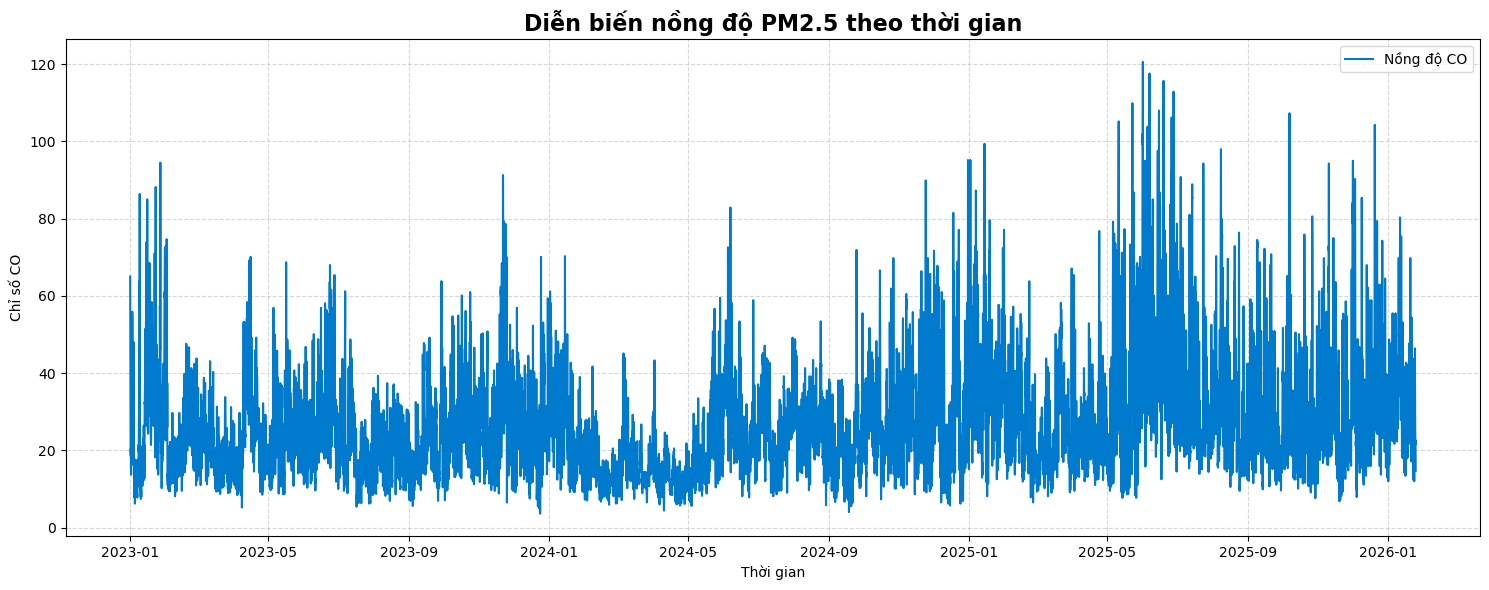

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Đảm bảo cột thời gian đúng định dạng (Quan trọng!)
# Thay 'time' bằng tên cột thời gian thực tế của bạn (ví dụ: 'date', 'datetime'...)
df['time'] = pd.to_datetime(df['time']) 

# 2. Vẽ biểu đồ
plt.figure(figsize=(15, 6)) # Kéo dài chiều ngang cho dễ nhìn

plt.plot(df['time'], df['PM2.5'], 
         color='#007acc',      # Màu xanh dịu mắt
         linewidth=1.5,        # Độ dày đường
         linestyle='-',        # Kiểu đường liền
         label='Nồng độ CO')

# 3. Trang trí cho đẹp
plt.title('Diễn biến nồng độ PM2.5 theo thời gian', fontsize=16, fontweight='bold')
plt.xlabel('Thời gian')
plt.ylabel('Chỉ số CO')
plt.grid(True, linestyle='--', alpha=0.5) # Thêm lưới mờ để dễ dóng số
plt.legend() # Hiện chú thích

plt.tight_layout()
plt.show()

In [4]:
# --- 1. KIỂM TRA SỐC ---
print("Max PM2.5 trước khi lọc:", df['PM2.5'].max())
print("Max CO trước khi lọc:", df['CO'].max())

# --- 2. THIẾT LẬP NGƯỠNG TRẦN (THRESHOLD) ---
# Theo tiêu chuẩn EPA:
# - PM2.5 > 500 là mức "Nguy hại" kịch khung (Hazardous). 
# - Tuy nhiên, để an toàn cho AI, ta có thể cắt ở mức 600-800 (tránh xóa nhầm sự kiện cháy lớn).
# - Nhưng 60,000 thì chắc chắn là lỗi cảm biến.

# Xử lý PM2.5: Những ông nào > 800 thì coi như lỗi -> biến thành NaN
df['PM2.5'] = df['PM2.5'].mask(df['PM2.5'] > 800, np.nan)

# Xử lý CO: Những ông nào > 3000 thì biến thành NaN (CO thực tế hiếm khi quá 1000)
df['CO'] = df['CO'].mask(df['CO'] > 3000, np.nan)

# Xử lý PM10 (nếu có): Thường < 1000
if 'PM10' in df.columns:
    df['PM10'] = df['PM10'].mask(df['PM10'] > 1200, np.nan)

# --- 3. LẤP LỖ TRỐNG (INTERPOLATE) ---
# Sau khi biến rác thành NaN, ta nhờ hàng xóm điền dùm (nội suy)
df = df.interpolate(method='linear', limit_direction='both')

print("-" * 20)
print("✅ Đã dọn dẹp xong!")
print("Max PM2.5 sau khi lọc:", df['PM2.5'].max()) # Mong đợi: < 800
print("Max CO sau khi lọc:", df['CO'].max())       # Mong đợi: < 3000

Max PM2.5 trước khi lọc: 120.6
Max CO trước khi lọc: 5784.0
--------------------
✅ Đã dọn dẹp xong!
Max PM2.5 sau khi lọc: 120.6
Max CO sau khi lọc: 2999.0


In [5]:
print("\n--- Số lượng giá trị Null trên mỗi cột ---")
print(df.isnull().sum())



--- Số lượng giá trị Null trên mỗi cột ---
time           0
PM10           0
PM2.5          0
CO             0
NO2            0
O3             0
SO2            0
AQI            0
UV             0
Temperature    0
Humidity       0
Rain           0
Wind_Speed     0
Wind_Dir       0
dtype: int64


In [6]:
df['CO']

0        993.0
1        846.0
2        821.0
3        834.0
4        838.0
         ...  
26875    717.0
26876    652.0
26877    593.0
26878    547.0
26879    518.0
Name: CO, Length: 26880, dtype: float64

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

# --- 1. HÀM HỖ TRỢ ---
def create_time_features(df, time_col='time'):
    df[time_col] = pd.to_datetime(df[time_col])
    df['hour'] = df[time_col].dt.hour
    df['month'] = df[time_col].dt.month
    df['day_of_week'] = df[time_col].dt.dayofweek
    return df

def cyclical_encode(df, col, max_val):
    df[col + '_sin'] = np.sin(2 * np.pi * df[col] / max_val)
    df[col + '_cos'] = np.cos(2 * np.pi * df[col] / max_val)
    return df

# --- 2. QUY TRÌNH XỬ LÝ CHÍNH ---

print("--- BẮT ĐẦU FEATURE ENGINEERING (BẢN FIX LỖI THỨ TỰ) ---")

# BƯỚC 1: Xử lý Thời gian
df = create_time_features(df)

# BƯỚC 2: Cyclical Encoding
df = cyclical_encode(df, 'hour', 24)
df = cyclical_encode(df, 'month', 12)
df = cyclical_encode(df, 'day_of_week', 7)
if 'Wind_Dir' in df.columns:
    df = cyclical_encode(df, 'Wind_Dir', 360)

# --- BƯỚC QUAN TRỌNG NHẤT: LỌC RÁC (Làm sạch TRƯỚC khi Log) ---
# Phải lọc ngay ở dữ liệu gốc thì Log mới sạch được
print("Max PM2.5 gốc:", df['PM2.5'].max())

# 1. Xử lý CO (như bạn đã làm)
df['CO'] = df['CO'].mask(df['CO'] > 2000, np.nan)

# 2. Xử lý PM2.5 (Thủ phạm gây ra số 60.000)
# Ngưỡng an toàn là 1000. Lớn hơn 1000 chắc chắn là lỗi cảm biến hoặc cháy rừng (bỏ qua để train cho ổn định)
df['PM2.5'] = df['PM2.5'].mask(df['PM2.5'] > 1000, np.nan)

# 3. Nội suy ngay lập tức để lấp đầy các khoảng vừa xóa
df = df.interpolate(method='linear', limit_direction='both')

print("Max PM2.5 sau khi lọc:", df['PM2.5'].max()) # Mong đợi: < 1000

# BƯỚC 3: Log Transformation
pollutants = ['PM10', 'PM2.5', 'CO', 'NO2', 'O3', 'SO2', 'AQI']
cols_to_log = [c for c in pollutants if c in df.columns]

for col in cols_to_log:
    # Kẹp giá trị âm về 0
    df[col] = df[col].clip(lower=0.0) 
    # Log transform
    df[f'{col}_log'] = np.log1p(df[col])

# BƯỚC 4: Chọn lọc Features
# Lưu ý: Bỏ các cột gốc, chỉ lấy cột _log và cột _sin/_cos
drop_cols = ['time', 'hour', 'month', 'day_of_week', 'Wind_Dir'] + cols_to_log
features_final = [c for c in df.columns if c not in drop_cols]

# Xử lý Inf/NaN lần cuối cho chắc ăn (dù bước trên đã làm sạch rồi)
df[features_final] = df[features_final].replace([np.inf, -np.inf], np.nan)
df[features_final] = df[features_final].fillna(0)

print(f"-> Số lượng features: {len(features_final)}")

# BƯỚC 5: Robust Scaler
scaler = RobustScaler()
try:
    df_scaled = pd.DataFrame(scaler.fit_transform(df[features_final]), 
                             columns=features_final, 
                             index=df.index)
    print("✅ Đã xử lý xong! Dữ liệu bao sạch.")
    display(df_scaled.head())
    
    # Kiểm tra nhanh xem còn thằng nào quá lớn không (sau khi log và scale)
    print("Max value trong df_scaled:", df_scaled.max().max())
    
except ValueError as e:
    print("❌ Vẫn còn lỗi:", e)

--- BẮT ĐẦU FEATURE ENGINEERING (BẢN FIX LỖI THỨ TỰ) ---
Max PM2.5 gốc: 120.6
Max PM2.5 sau khi lọc: 120.6
-> Số lượng features: 20
✅ Đã xử lý xong! Dữ liệu bao sạch.


,UV,Temperature,Humidity,Rain,Wind_Speed,hour_sin,hour_cos,month_sin,month_cos,day_of_week_sin,day_of_week_cos,Wind_Dir_sin,Wind_Dir_cos,PM10_log,PM2.5_log,CO_log,NO2_log,O3_log,SO2_log,AQI_log
0,0.0,-0.875,-0.809524,0.0,0.666667,-4.329780e-17,0.707107,0.5,0.633975,-0.5,0.554958,0.048162,1.215964,1.793400,1.511408,0.829328,1.203138,-0.399155,0.771942,1.392375
1,0.0,-1.000,-0.714286,0.0,0.500000,1.830127e-01,0.683013,0.5,0.633975,-0.5,0.554958,0.083948,1.207829,1.636824,1.367829,0.640056,0.999912,-0.319698,0.546590,1.392375
2,0.0,-1.125,-0.571429,0.0,0.100000,3.535534e-01,0.612372,0.5,0.633975,-0.5,0.554958,-0.060590,1.226462,1.586146,1.316759,0.604622,0.928626,-0.371694,0.473974,1.372636
3,0.0,-1.250,-0.428571,0.0,0.166667,5.000000e-01,0.500000,0.5,0.633975,-0.5,0.554958,-0.060590,1.226462,1.521958,1.258506,0.623180,0.898099,-0.488365,0.458100,1.352749
4,0.0,-1.275,-0.476190,0.0,0.100000,6.123724e-01,0.353553,0.5,0.633975,-0.5,0.554958,-0.096973,1.225293,1.294251,1.047289,0.628832,0.828952,-0.554559,0.404979,1.312517


Max value trong df_scaled: 221.99999999999997


In [8]:
# --- 1. TÌM LẠI VỊ TRÍ CỘT TARGET (Fix lỗi NameError) ---
# --- HÀM TẠO DATASET ĐA BƯỚC (Cần chạy cell này trước) ---
def create_dataset_multistep(dataset, target_col_index, n_past=24, n_future=24):
    dataX, dataY = [], []
    data_array = dataset.values
    
    # Loop đến giới hạn an toàn để không bị hết dữ liệu tương lai
    for i in range(n_past, len(data_array) - n_future + 1):
        # 1. Input: Vẫn là 24 giờ quá khứ
        window = data_array[i - n_past : i, :] 
        dataX.append(window)
        
        # 2. Target: Lấy MỘT CHUỖI từ i đến i + n_future (24 giờ tiếp theo)
        # Chỉ lấy cột mục tiêu (PM2.5)
        target_seq = data_array[i : i + n_future, target_col_index]
        dataY.append(target_seq)
        
    return np.array(dataX), np.array(dataY)

print("✅ Đã khai báo xong hàm create_dataset_multistep!")

# SỬA Ở ĐÂY: Đổi 'PM2.5' thành 'PM2.5_log' vì cột gốc đã bị drop rồi
target_column_name = 'PM2.5_log'  

# Kiểm tra xem cột đó nằm ở số thứ tự bao nhiêu trong bảng df_scaled
if target_column_name in df_scaled.columns:
    target_idx = df_scaled.columns.get_loc(target_column_name)
    print(f"🎯 Cột mục tiêu '{target_column_name}' nằm ở vị trí index: {target_idx}")
else:
    print(f"❌ Không tìm thấy cột '{target_column_name}'. Kiểm tra lại tên cột trong df_scaled!")
    # In ra danh sách cột hiện có để bạn dễ debug
    print("Các cột hiện có:", df_scaled.columns)
    target_idx = 0

# ... (Các phần dưới giữ nguyên) ...

# --- 2. THIẾT LẬP THAM SỐ ĐA BƯỚC ---
N_PAST = 24   # Nhìn lại 24h
N_FUTURE = 24 # Dự báo 24h tới (Multi-step)

# --- 3. TẠO DATASET ---
# Giờ thì biến target_idx đã có, chạy dòng này sẽ ngon lành
X, y = create_dataset_multistep(df_scaled, target_idx, n_past=N_PAST, n_future=N_FUTURE)

print("--- KẾT QUẢ SHAPE MỚI ---")
print(f"X shape: {X.shape} (Input: 24h quá khứ)")
print(f"y shape: {y.shape} (Output: 24h tương lai)") 

# --- 4. CHIA TRAIN/VAL/TEST ---
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size : train_size + val_size], y[train_size : train_size + val_size]
X_test, y_test = X[train_size + val_size:], y[train_size + val_size:]

print("✅ Đã chia xong dữ liệu cho bài toán dự báo 24h!")

✅ Đã khai báo xong hàm create_dataset_multistep!
🎯 Cột mục tiêu 'PM2.5_log' nằm ở vị trí index: 14
--- KẾT QUẢ SHAPE MỚI ---
X shape: (26833, 24, 20) (Input: 24h quá khứ)
y shape: (26833, 24) (Output: 24h tương lai)
✅ Đã chia xong dữ liệu cho bài toán dự báo 24h!


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

print("🏗️ Xây dựng Model phiên bản 'Cai Nghiện Học Vẹt' (Anti-Overfitting)...")

n_timesteps = X_train.shape[1] # 24
n_features = X_train.shape[2]
output_units = 24 

model = Sequential()

# Tầng 1: Giảm units xuống 64, thêm kernel_regularizer
model.add(Input(shape=(n_timesteps, n_features)))
model.add(LSTM(units=64, return_sequences=True, kernel_regularizer=l2(0.001))) 
model.add(BatchNormalization()) 
model.add(Dropout(0.3)) # Tăng Dropout lên 0.3 để cấm học vẹt

# Tầng 2: Giảm units xuống 32
model.add(LSTM(units=32, return_sequences=False, kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Tầng Output
model.add(Dense(units=32, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dense(units=output_units)) 

# Compile: Dùng MAE để bắt đỉnh, giảm learning rate xuống thấp
model.compile(optimizer=Adam(learning_rate=0.0005), loss='mae') 

model.summary()

🏗️ Xây dựng Model phiên bản 'Cai Nghiện Học Vẹt' (Anti-Overfitting)...
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 24, 64)            21760     
                                                                 
 batch_normalization (BatchN  (None, 24, 64)           256       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 24, 64)            0         
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 batch_normalization_1 (Batc  (None, 32)               128       
 hNormalization)                                                 
                                                   

In [10]:
# 1. Tính toán index để cắt
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)
# Test size tự động là phần còn lại

# 2. Cắt dữ liệu (Slicing)
X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size : train_size + val_size], y[train_size : train_size + val_size]
X_test, y_test = X[train_size + val_size:], y[train_size + val_size:]

print(f"✅ Train shape: {X_train.shape} - Dùng để dạy Model")
print(f"✅ Val shape:   {X_val.shape}   - Dùng để chỉnh Model")
print(f"✅ Test shape:  {X_test.shape}  - Dùng để kiểm tra cuối cùng")

✅ Train shape: (18783, 24, 20) - Dùng để dạy Model
✅ Val shape:   (4024, 24, 20)   - Dùng để chỉnh Model
✅ Test shape:  (4026, 24, 20)  - Dùng để kiểm tra cuối cùng


In [11]:
import tensorflow as tf
print("Phiên bản TF:", tf.__version__)
print("GPU có sẵn:", tf.config.list_physical_devices('GPU'))

Phiên bản TF: 2.10.1
GPU có sẵn: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

model = Sequential()
model.add(Input(shape=(X_train.shape[1], X_train.shape[2]))) # (24, n_features)

# Tăng sức mạnh cho LSTM vì bài toán khó hơn
model.add(LSTM(units=128, return_sequences=True)) # Tăng units lên 128
model.add(Dropout(0.2))

model.add(LSTM(units=64, return_sequences=False))
model.add(Dropout(0.2))

# --- QUAN TRỌNG: OUTPUT LAYER ---
# Units = N_FUTURE (24) để dự báo 24 bước
model.add(Dense(units=N_FUTURE)) 

model.compile(optimizer='adam', loss='mse') # Dùng MSE cho bài toán này
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 24, 128)           76288     
                                                                 
 dropout_2 (Dropout)         (None, 24, 128)           0         
                                                                 
 lstm_3 (LSTM)               (None, 64)                49408     
                                                                 
 dropout_3 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 24)                1560      
                                                                 
Total params: 127,256
Trainable params: 127,256
Non-trainable params: 0
_________________________________________________________________


In [13]:
import time
# --- THÊM DÒNG NÀY ĐỂ FIX LỖI ---
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Cấu hình Callbacks (Giữ nguyên như cũ)
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    # Đổi tên file lưu thành multistep để không ghi đè model cũ
    ModelCheckpoint('best_aqi_multistep.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

print("🚀 Bắt đầu Train với RTX 4070...")

# --- BẮT ĐẦU BẤM GIỜ ---
start_time = time.time()

# Quá trình train
history = model.fit(
    X_train, y_train,
    epochs=100,             
    batch_size=64,          
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1 # verbose=1 sẽ hiển thị thời gian chạy của từng Epoch luôn
)

# --- DỪNG BẤM GIỜ ---
end_time = time.time()

# Tính toán thời gian
training_time = end_time - start_time
print(f"🎉 Đã Train xong trong: {training_time:.2f} giây")
print(f"⏱️ Tương đương: {training_time/60:.2f} phút")

🚀 Bắt đầu Train với RTX 4070...
Epoch 1/100
289/294 [============================>.] - ETA: 0s - loss: 0.2526
Epoch 1: val_loss improved from inf to 0.39000, saving model to best_aqi_multistep.keras
294/294 [==============================] - 7s 10ms/step - loss: 0.2521 - val_loss: 0.3900
Epoch 2/100
289/294 [============================>.] - ETA: 0s - loss: 0.1868
Epoch 2: val_loss did not improve from 0.39000
294/294 [==============================] - 2s 8ms/step - loss: 0.1865 - val_loss: 0.4078
Epoch 3/100
292/294 [============================>.] - ETA: 0s - loss: 0.1445
Epoch 3: val_loss did not improve from 0.39000
294/294 [==============================] - 2s 8ms/step - loss: 0.1444 - val_loss: 0.4260
Epoch 4/100
289/294 [============================>.] - ETA: 0s - loss: 0.1133
Epoch 4: val_loss did not improve from 0.39000
294/294 [==============================] - 2s 8ms/step - loss: 0.1132 - val_loss: 0.4311
Epoch 5/100
294/294 [==============================] - ETA: 0s - loss

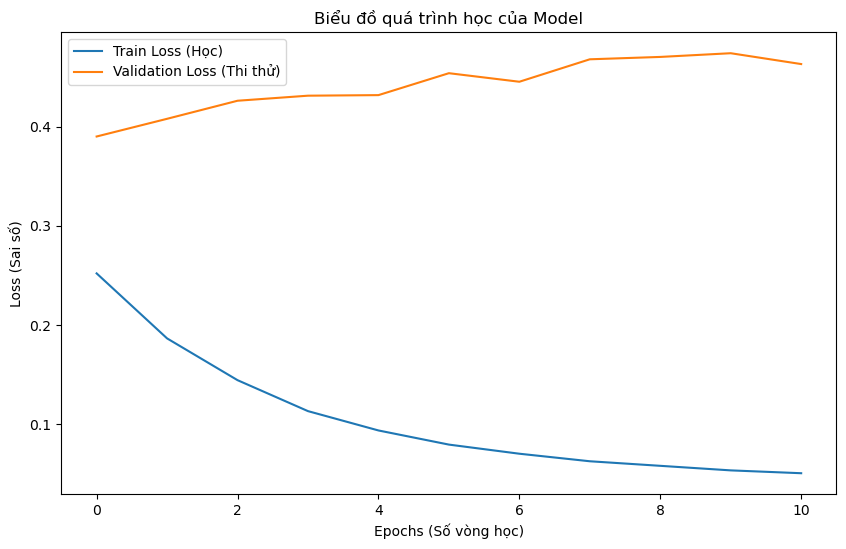

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss (Học)')
plt.plot(history.history['val_loss'], label='Validation Loss (Thi thử)')
plt.title('Biểu đồ quá trình học của Model')
plt.xlabel('Epochs (Số vòng học)')
plt.ylabel('Loss (Sai số)')
plt.legend()
plt.show()

--- BẮT ĐẦU ĐÁNH GIÁ TRÊN TẬP TEST (MULTI-STEP) ---
126/126 [==============================] - 1s 3ms/step
Đang chuyển đổi đơn vị (Inverse Scale)...
Detected Log transform -> Applying np.expm1
------------------------------
📉 KẾT QUẢ ĐÁNH GIÁ (Trung bình cho 24h dự báo):
   RMSE: 12.28 µg/m³
   MAE:  8.87 µg/m³
------------------------------


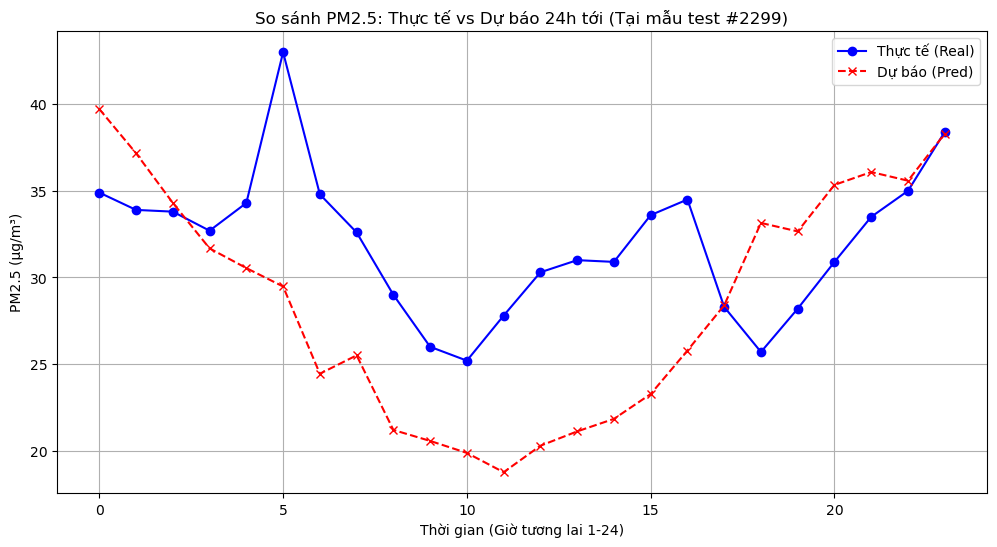

In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("--- BẮT ĐẦU ĐÁNH GIÁ TRÊN TẬP TEST (MULTI-STEP) ---")

# 1. Dự báo
# Kết quả trả về là ma trận (Số mẫu, 24)
y_pred_scaled = model.predict(X_test)

# 2. Hàm hỗ trợ Inverse Scale (Đưa về đơn vị gốc µg/m³)
# Vì scaler của bạn fit trên nhiều cột (n_features), nên muốn inverse 1 cột target
# ta phải tạo ra một ma trận giả (dummy) có đủ số cột y như lúc train.
def inverse_transform_multistep(y_scaled, scaler, n_features, target_col_idx):
    # y_scaled đang là (Samples, 24)
    # Ta phải duỗi nó ra hoặc lặp qua từng mẫu. 
    # Cách nhanh nhất để lấy RMSE tổng quát:
    
    # Tạo ma trận dummy: (Samples * 24, n_features)
    # Lưu ý: Cách này chỉ mang tính ước lượng nhanh cho biến Target
    
    # Cách đơn giản hơn: Chỉ inverse thủ công dựa trên min/max hoặc scale của cột target
    # (Nhưng vì dùng RobustScaler nên hơi khó tính tay).
    
    # => Dùng cách tạo dummy matrix cho từng bước dự báo (hơi chậm xíu nhưng chuẩn)
    n_samples = y_scaled.shape[0]
    n_steps = y_scaled.shape[1] # 24
    
    y_rescaled = np.zeros((n_samples, n_steps))
    
    # Lặp qua từng bước thời gian (cột) để inverse
    # Lưu ý: Đây là cách gần đúng nếu scaler fit trên dữ liệu 2D. 
    # Để chính xác tuyệt đối, ta cần scale riêng cột Target ngay từ đầu.
    # Tuy nhiên, ta có thể "hack" bằng cách tạo dummy row.
    
    dummy = np.zeros((n_samples, n_features))
    
    for i in range(n_steps):
        # Lấy cột thứ i của dự báo (Dự báo giờ thứ i)
        dummy[:, target_col_idx] = y_scaled[:, i]
        # Inverse
        inv = scaler.inverse_transform(dummy)
        # Lấy lại cột target
        y_rescaled[:, i] = inv[:, target_col_idx]
        
    return y_rescaled

# Thực hiện Inverse
# Lưu ý: target_idx là biến bạn đã tìm ở cell trước (chắc là index của PM2.5_log)
print("Đang chuyển đổi đơn vị (Inverse Scale)...")
n_features = X_train.shape[2]
y_pred = inverse_transform_multistep(y_pred_scaled, scaler, n_features, target_idx)
y_true = inverse_transform_multistep(y_test, scaler, n_features, target_idx)

# Nếu bạn dùng Log lúc train, giờ phải Expm1 để về số thực
# (Kiểm tra xem tên cột target có chữ '_log' không)
if 'log' in target_column_name:
    print("Detected Log transform -> Applying np.expm1")
    y_pred = np.expm1(y_pred)
    y_true = np.expm1(y_true)

# Kẹp giá trị (không cho âm)
y_pred = np.maximum(y_pred, 0)
y_true = np.maximum(y_true, 0)

# 3. Tính sai số
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print("-" * 30)
print(f"📉 KẾT QUẢ ĐÁNH GIÁ (Trung bình cho 24h dự báo):")
print(f"   RMSE: {rmse:.2f} µg/m³")
print(f"   MAE:  {mae:.2f} µg/m³")
print("-" * 30)

# 4. Vẽ biểu đồ so sánh 1 mẫu ngẫu nhiên
# Chọn 1 thời điểm bất kỳ trong tập test để xem model dự báo 24h tới thế nào
import random
sample_idx = random.randint(0, len(y_test) - 1)

plt.figure(figsize=(12, 6))
plt.plot(y_true[sample_idx], label='Thực tế (Real)', marker='o', color='blue')
plt.plot(y_pred[sample_idx], label='Dự báo (Pred)', marker='x', linestyle='--', color='red')
plt.title(f'So sánh PM2.5: Thực tế vs Dự báo 24h tới (Tại mẫu test #{sample_idx})')
plt.xlabel('Thời gian (Giờ tương lai 1-24)')
plt.ylabel('PM2.5 (µg/m³)')
plt.legend()
plt.grid(True)
plt.show()

--- BẮT ĐẦU ĐÁNH GIÁ TRÊN TẬP TEST (MULTI-STEP 24H) ---
126/126 [==============================] - 0s 3ms/step
🔄 Đang xử lý Inverse Scale & Log Transform...
✅ Đã chuyển đổi dữ liệu về đơn vị gốc (µg/m³)!
----------------------------------------
📉 KẾT QUẢ ĐÁNH GIÁ MODEL DỰ BÁO 24H:
   RMSE Trung bình: 12.28 µg/m³
   MAE Trung bình:  8.87 µg/m³
   R2 Score:        0.2291
----------------------------------------


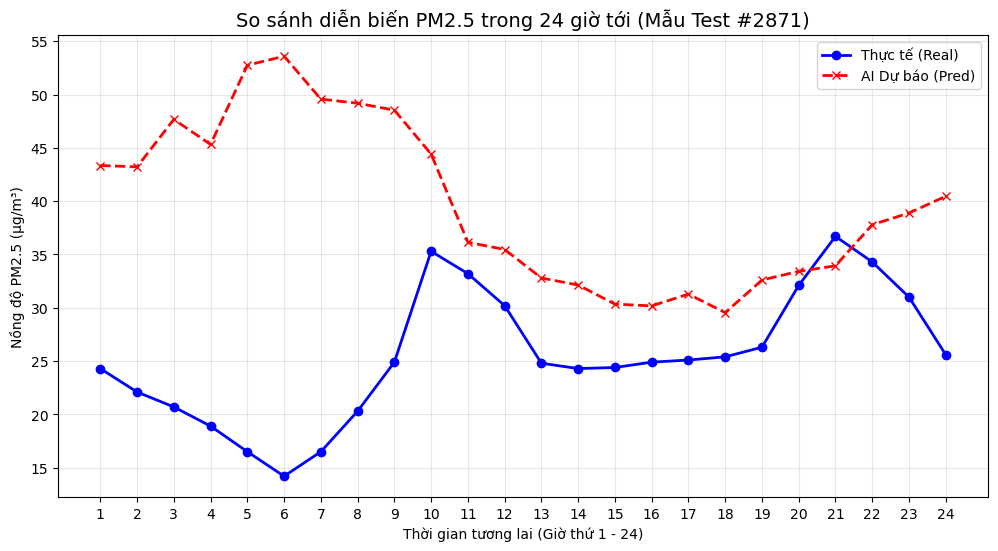

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math
import random

print("--- BẮT ĐẦU ĐÁNH GIÁ TRÊN TẬP TEST (MULTI-STEP 24H) ---")

# 1. Dự báo
# Kết quả trả về là ma trận (Số mẫu, 24)
y_pred_scaled = model.predict(X_test)

# 2. Xử lý nghịch đảo (Inverse Transform) cho cả 24 cột
# Vì Scaler fit trên nhiều cột, ta phải dùng mẹo "ma trận giả" để inverse từng bước
print("🔄 Đang xử lý Inverse Scale & Log Transform...")

n_features = X_train.shape[2] # Số lượng features lúc train
n_steps = 24 # 24 giờ dự báo

# Hàm hỗ trợ inverse cho ma trận 24 bước
def inverse_multistep(y_data_scaled, scaler, target_idx, n_features):
    n_samples = y_data_scaled.shape[0]
    y_restored = np.zeros_like(y_data_scaled)
    
    # Tạo ma trận giả để lừa scaler
    dummy = np.zeros((n_samples, n_features))
    
    for i in range(y_data_scaled.shape[1]): # Lặp qua 24 cột
        # Lấy dữ liệu của giờ thứ i
        dummy[:, target_idx] = y_data_scaled[:, i]
        # Inverse
        inv = scaler.inverse_transform(dummy)
        # Lấy lại cột target cất vào kết quả
        y_restored[:, i] = inv[:, target_idx]
        
    return y_restored

# Gọi hàm inverse
y_pred_inv = inverse_multistep(y_pred_scaled, scaler, target_idx, n_features)
y_true_inv = inverse_multistep(y_test, scaler, target_idx, n_features)

# 3. Nghịch đảo Log (QUAN TRỌNG: VÌ CELL 3 BẠN ĐÃ LOG NÊN GIỜ PHẢI EXP)
# Kiểm tra tên cột target, nếu là PM2.5_log thì phải exp
y_pred_final = np.expm1(y_pred_inv) 
y_true_final = np.expm1(y_true_inv)

# Kẹp giá trị (không cho âm)
y_pred_final = np.maximum(y_pred_final, 0)
y_true_final = np.maximum(y_true_final, 0)

print("✅ Đã chuyển đổi dữ liệu về đơn vị gốc (µg/m³)!")

# 4. Tính toán các chỉ số (Tính trung bình cho cả 24 giờ)
rmse = math.sqrt(mean_squared_error(y_true_final, y_pred_final))
mae = mean_absolute_error(y_true_final, y_pred_final)
r2 = r2_score(y_true_final, y_pred_final) # R2 cho mảng đa chiều

print("-" * 40)
print(f"📉 KẾT QUẢ ĐÁNH GIÁ MODEL DỰ BÁO 24H:")
print(f"   RMSE Trung bình: {rmse:.2f} µg/m³")
print(f"   MAE Trung bình:  {mae:.2f} µg/m³")
print(f"   R2 Score:        {r2:.4f}")
print("-" * 40)

# 5. VẼ BIỂU ĐỒ (Cách vẽ khác: Chọn 1 mẫu bất kỳ để soi 24h tới)
# Chọn ngẫu nhiên 1 thời điểm trong tập test
sample_idx = random.randint(0, len(y_test) - 1)

plt.figure(figsize=(12, 6))

# Vẽ đường thực tế
plt.plot(range(1, 25), y_true_final[sample_idx], 
         label='Thực tế (Real)', marker='o', color='blue', linewidth=2)

# Vẽ đường dự báo
plt.plot(range(1, 25), y_pred_final[sample_idx], 
         label='AI Dự báo (Pred)', marker='x', color='red', linestyle='--', linewidth=2)

plt.title(f'So sánh diễn biến PM2.5 trong 24 giờ tới (Mẫu Test #{sample_idx})', fontsize=14)
plt.xlabel('Thời gian tương lai (Giờ thứ 1 - 24)')
plt.ylabel('Nồng độ PM2.5 (µg/m³)')
plt.xticks(range(1, 25)) # Hiện đủ số 1 đến 24
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split

# 1. Load và xử lý sơ bộ
# Giả sử df đã load từ file csv của bạn
df['time'] = pd.to_datetime(df['time'])

# Lọc rác (quan trọng)
df['PM2.5'] = df['PM2.5'].mask(df['PM2.5'] > 800, np.nan) # Bỏ giá trị > 800
df = df.interpolate(method='linear', limit_direction='both')

# 2. Tạo Features cơ bản
df['hour'] = df['time'].dt.hour
df['month'] = df['time'].dt.month
# Cyclical encoding
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# 3. QUAN TRỌNG: Scale Target Riêng biệt
# Giúp việc inverse sau này cực dễ, không bị lỗi dimension
target_col = 'PM2.5'
feature_cols = ['PM2.5', 'hour_sin', 'hour_cos', 'month'] # Thêm các cột khác nếu muốn (CO, Temp...)

# Scaler cho Input (Features)
scaler_X = RobustScaler()
df_scaled = scaler_X.fit_transform(df[feature_cols])

# Scaler cho Output (Target) - Dùng MinMaxScaler cho target về [0,1] để model dễ học
scaler_y = MinMaxScaler(feature_range=(0, 1))
scaler_y.fit(df[[target_col]]) # Fit riêng cột PM2.5

# 4. Hàm tạo Dataset (Sliding Window)
def create_dataset(dataset, target_values, n_past=24, n_future=24):
    X, y = [], []
    for i in range(n_past, len(dataset) - n_future + 1):
        X.append(dataset[i - n_past : i, :]) # Lấy n_past giờ quá khứ của ALL features
        y.append(target_values[i : i + n_future, 0]) # Lấy n_future giờ tương lai của TARGET
    return np.array(X), np.array(y)

# Thiết lập tham số
N_PAST = 24
N_FUTURE = 24

# Tạo dữ liệu: Input lấy từ df_scaled, Output lấy từ dữ liệu gốc đã scale riêng
# Lưu ý: target_values phải lấy từ scaler_y.transform
target_scaled = scaler_y.transform(df[[target_col]])

X, y = create_dataset(df_scaled, target_scaled, N_PAST, N_FUTURE)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, shuffle=True)

print(f"✅ Đã trộn và chia dữ liệu:")
print(f"   X_train: {X_train.shape} - (Học cả năm)")
print(f"   X_val:   {X_val.shape}   - (Thi thử rải rác)")
print(f"   X_test:  {X_test.shape}  - (Thi thật rải rác)")

✅ Đã trộn và chia dữ liệu:
   X_train: (18783, 24, 4) - (Học cả năm)
   X_val:   (4025, 24, 4)   - (Thi thử rải rác)
   X_test:  (4025, 24, 4)  - (Thi thật rải rác)


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

# Xây dựng Model "Siêu Kỷ Luật"
model = Sequential()

model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))

# Layer 1: GRU + L2 Regularization (Phạt nặng nếu học vẹt)
# kernel_regularizer=l2(0.01): Đây là cái phanh kìm hãm model
model.add(GRU(units=32, return_sequences=False, kernel_regularizer=l2(0.02))) 

# Tăng Dropout lên 0.5 (Tắt một nửa não bộ để ép nửa kia phải tư duy)
model.add(Dropout(0.5)) 

# Output Layer
model.add(Dense(units=24)) 

# Compile: Dùng MAE thay vì MSE
# MAE giúp model đỡ sợ các giá trị ngoại lai (outliers) hơn
model.compile(optimizer=Adam(learning_rate=0.0005), loss='mae')

# Callbacks: Cho phép dừng sớm hơn nếu không khá lên
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
]

print("🚀 Bắt đầu Train phiên bản Heavy Regularization...")
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)
# Xây dựng Model
model = Sequential()

# Input Layer
model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))

# Layer 1: GRU 
# GRU nhẹ hơn LSTM, rất phù hợp khi dữ liệu nhiễu
model.add(GRU(units=64, return_sequences=False)) 
# return_sequences=False vì ta chỉ cần trạng thái cuối cùng để dự báo tương lai
# Chỉ dùng 1 lớp GRU thôi để tránh Overfitting (Hình 2 của bạn)

model.add(Dropout(0.2)) # Chống học vẹt

# Output Layer: 24 nơ-ron cho 24 giờ
model.add(Dense(units=24)) 

# Compile
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Callbacks thông minh
callbacks = [
    # Nếu loss đi ngang 5 vòng -> Giảm tốc độ học 5 lần để len lỏi vào điểm tối ưu
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001, verbose=1),
    # Nếu loss đi ngang 15 vòng -> Dừng luôn
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
]

print("🚀 Bắt đầu Train lại từ đầu với GRU...")
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32, # Batch nhỏ giúp model học kỹ hơn
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

🚀 Bắt đầu Train phiên bản Heavy Regularization...
Epoch 1/100
587/587 [==============================] - 4s 6ms/step - loss: 0.1474 - val_loss: 0.0731 - lr: 5.0000e-04
Epoch 2/100
587/587 [==============================] - 4s 6ms/step - loss: 0.0718 - val_loss: 0.0672 - lr: 5.0000e-04
Epoch 3/100
587/587 [==============================] - 3s 6ms/step - loss: 0.0678 - val_loss: 0.0644 - lr: 5.0000e-04
Epoch 4/100
587/587 [==============================] - 4s 6ms/step - loss: 0.0660 - val_loss: 0.0635 - lr: 5.0000e-04
Epoch 5/100
587/587 [==============================] - 6s 9ms/step - loss: 0.0650 - val_loss: 0.0625 - lr: 5.0000e-04
Epoch 6/100
587/587 [==============================] - 5s 9ms/step - loss: 0.0644 - val_loss: 0.0626 - lr: 5.0000e-04
Epoch 7/100
587/587 [==============================] - 5s 8ms/step - loss: 0.0639 - val_loss: 0.0618 - lr: 5.0000e-04
Epoch 8/100
587/587 [==============================] - 5s 8ms/step - loss: 0.0635 - val_loss: 0.0621 - lr: 5.0000e-04
Epoch 

--- ĐANG ĐÁNH GIÁ ---
126/126 [==============================] - 1s 3ms/step

📉 KẾT QUẢ SAU KHI LÀM LẠI:
   RMSE Trung bình 24h: 6.90
   MAE Trung bình 24h:  5.02


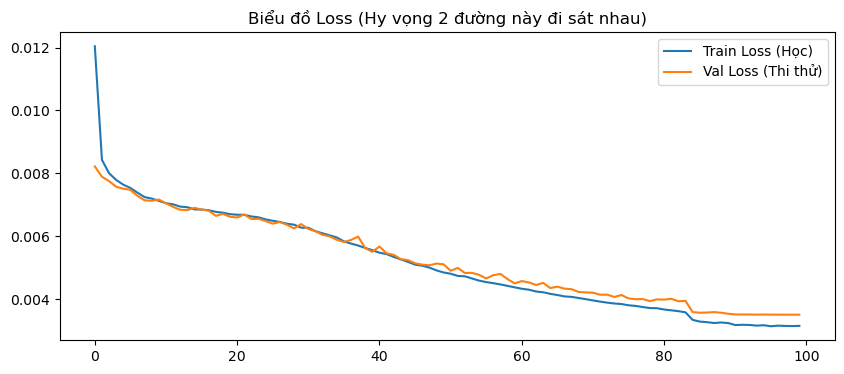

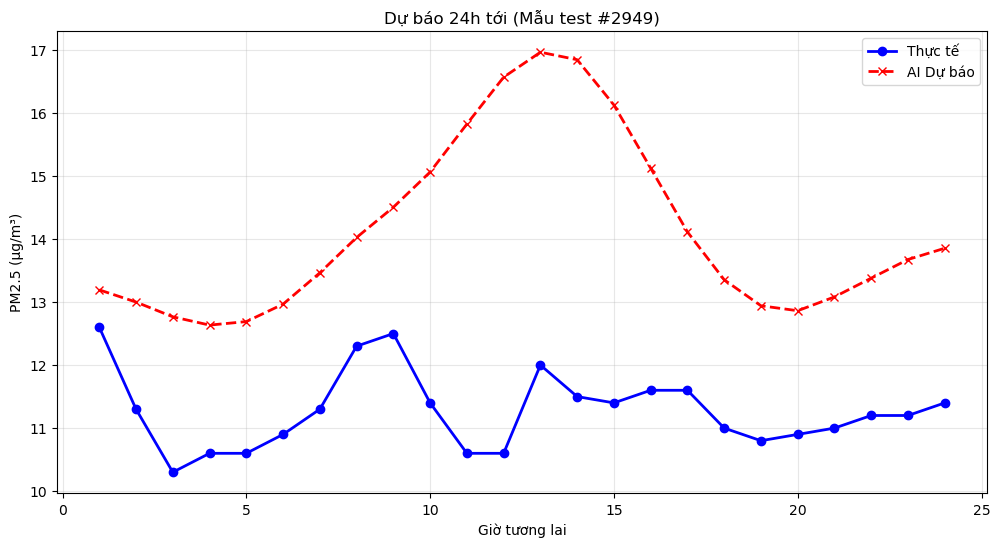

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import random

print("--- ĐANG ĐÁNH GIÁ ---")

# 1. Dự báo
y_pred_scaled = model.predict(X_test)

# 2. Inverse Scale (Cực dễ vì đã có scaler_y riêng)
# y_pred_scaled đang là (Samples, 24) -> Scaler_y hiểu được ngay
# Không cần dummy matrix nữa!
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

# Kẹp giá trị không cho âm (Safety first)
y_pred = np.maximum(y_pred, 0)
y_true = np.maximum(y_true, 0)

# 3. Tính chỉ số
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print(f"\n📉 KẾT QUẢ SAU KHI LÀM LẠI:")
print(f"   RMSE Trung bình 24h: {rmse:.2f}")
print(f"   MAE Trung bình 24h:  {mae:.2f}")

# 4. Vẽ biểu đồ Loss (Kiểm tra xem còn Overfit không)
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss (Học)')
plt.plot(history.history['val_loss'], label='Val Loss (Thi thử)')
plt.title('Biểu đồ Loss (Hy vọng 2 đường này đi sát nhau)')
plt.legend()
plt.show()

# 5. Vẽ biểu đồ dự báo 24h (Random 1 mẫu)
idx = random.randint(0, len(y_test)-1)
plt.figure(figsize=(12, 6))
plt.plot(range(1, 25), y_true[idx], 'b-o', label='Thực tế', linewidth=2)
plt.plot(range(1, 25), y_pred[idx], 'r--x', label='AI Dự báo', linewidth=2)
plt.title(f'Dự báo 24h tới (Mẫu test #{idx})')
plt.ylabel('PM2.5 (µg/m³)')
plt.xlabel('Giờ tương lai')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()